In [1]:
import numpy as np
import pandas as pd

def logistic_curve(x, r):
    return r * x * (1 - x)

r_value = 2.5
x_values = np.linspace(0, 1, 400)

df_rule = pd.DataFrame({
    'x_t': x_values,
    'x_next': logistic_curve(x_values, r_value),
    'r': r_value
})

df_rule


,x_t,x_next,r
0,0.000000,0.000000,2.5
1,0.002506,0.006250,2.5
2,0.005013,0.012469,2.5
3,0.007519,0.018656,2.5
4,0.010025,0.024811,2.5
...,...,...,...
395,0.989975,0.024811,2.5
396,0.992481,0.018656,2.5
397,0.994987,0.012469,2.5
398,0.997494,0.006250,2.5


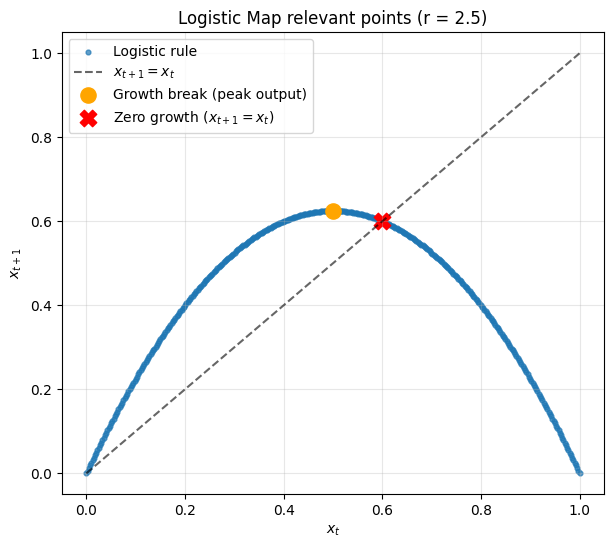

In [2]:
import matplotlib.pyplot as plt

# ---- Plot: x_t vs x_{t+1} ----
plt.figure(figsize=(7, 6))

# Logistic rule (parabola)
plt.scatter(df_rule['x_t'], df_rule['x_next'], s=12, alpha=0.7,
            label="Logistic rule")

# 45-degree line (identity)
plt.plot([0, 1], [0, 1], 'k--', alpha=0.6, label=r"$x_{t+1}=x_t$")

# -----------------------------
# Key points
# -----------------------------

# (1) Growth break / peak growth (maximum of parabola)
x_peak = 0.5
y_peak = r_value / 4

plt.scatter(
    [x_peak], [y_peak],
    color="orange", s=120, marker="o",
    label="Growth break (peak output)"
)

# (2) Zero-growth / equilibrium threshold
x_star = 1 - 1 / r_value

plt.scatter(
    [x_star], [x_star],
    color="red", s=140, marker="X",
    label=r"Zero growth ($x_{t+1}=x_t$)"
)

# -----------------------------
# Labels and layout
# -----------------------------
plt.xlabel(r"$x_t$")
plt.ylabel(r"$x_{t+1}$")
plt.title(rf"Logistic Map relevant points (r = {r_value})")

plt.legend()
plt.grid(alpha=0.3)
plt.show()


In [3]:
def logistic_series(r, x0=0.2, steps=200):
    xs = [x0]
    for _ in range(steps - 1):
        xs.append(r * xs[-1] * (1 - xs[-1]))
    return np.array(xs)

r_value = 2.5
x0 = 0.1
steps = 200
x_star = 1 - 1 / r_value

series = logistic_series(r_value, x0=x0, steps=steps)


In [4]:
series

array([0.1       , 0.225     , 0.4359375 , 0.61473999, 0.59208684,
       0.60380004, 0.59806388, 0.60095869, 0.59951836, 0.60024024,
       0.59987974, 0.6000601 , 0.59996994, 0.60001503, 0.59999249,
       0.60000376, 0.59999812, 0.60000094, 0.59999953, 0.60000023,
       0.59999988, 0.60000006, 0.59999997, 0.60000001, 0.59999999,
       0.6       , 0.6       , 0.6       , 0.6       , 0.6       ,
       0.6       , 0.6       , 0.6       , 0.6       , 0.6       ,
       0.6       , 0.6       , 0.6       , 0.6       , 0.6       ,
       0.6       , 0.6       , 0.6       , 0.6       , 0.6       ,
       0.6       , 0.6       , 0.6       , 0.6       , 0.6       ,
       0.6       , 0.6       , 0.6       , 0.6       , 0.6       ,
       0.6       , 0.6       , 0.6       , 0.6       , 0.6       ,
       0.6       , 0.6       , 0.6       , 0.6       , 0.6       ,
       0.6       , 0.6       , 0.6       , 0.6       , 0.6       ,
       0.6       , 0.6       , 0.6       , 0.6       , 0.6    

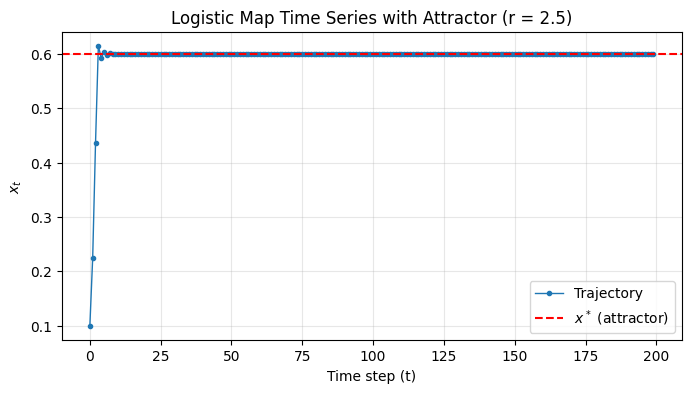

In [5]:
plt.figure(figsize=(8, 4))
plt.plot(series, marker='o', markersize=3, linewidth=1, label="Trajectory")
plt.axhline(x_star, color="red", linestyle="--", label=r"$x^*$ (attractor)")
plt.xlabel("Time step (t)")
plt.ylabel(r"$x_t$")
plt.title(rf"Logistic Map Time Series with Attractor (r = {r_value})")
plt.legend()
plt.grid(alpha=0.3)
plt.show()


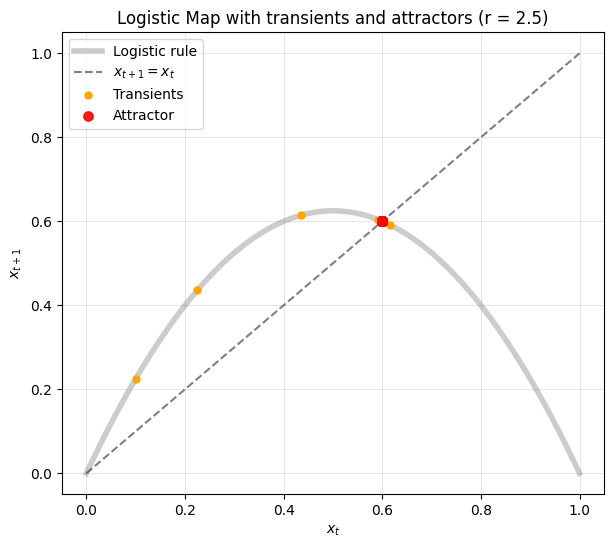

In [6]:
x_t = series[:-1]
x_next = series[1:]


# Parabola (rule geometry)
x_grid = np.linspace(0, 1, 400)
y_grid = r_value * x_grid * (1 - x_grid)

plt.figure(figsize=(7, 6))

# Logistic parabola
plt.plot(
    x_grid, y_grid, alpha=0.4,
    color="grey", linewidth=4,
    label="Logistic rule"
)

# 45-degree line
plt.plot(
    [0, 1], [0, 1],
    "k--", alpha=0.5,
    label=r"$x_{t+1} = x_t$"
)

# Transients
plt.scatter(
    x_t, x_next,
    s=25, color="orange",
    label="Transients",zorder=3
)

# Long-run / attractor
plt.scatter(
    x_t[-50:], x_next[-50:],
    s=45, color="red", alpha=0.9,
    label="Attractor",
    zorder=4
)


plt.xlabel(r"$x_t$")
plt.ylabel(r"$x_{t+1}$")
plt.title(rf"Logistic Map with transients and attractors (r = {r_value})")
plt.legend()
plt.grid(alpha=0.3)
plt.show()



In [7]:
from matplotlib.animation import FuncAnimation

def animate_cobweb(r, x0=0.1, n_iter=50, interval=50):
    # Setup the figure
    fig, ax = plt.subplots(figsize=(6, 6))
    xs = np.linspace(0, 1, 500)

    # Static background elements
    ax.plot(xs, r * xs * (1 - xs), 'k', lw=1.2, label=f"$f(x) = {r}x(1-x)$")
    ax.plot(xs, xs, 'k--', alpha=0.4, label="$y=x$")

    # Dynamic elements
    line, = ax.plot([], [], 'r-', lw=1, alpha=0.8)
    dot, = ax.plot([], [], 'ro', markersize=4)

    # Calculate trajectory coordinates efficiently
    # (x0,0) -> (x0,x1) -> (x1,x1) -> (x1,x2) -> (x2,x2)...
    px, py = [x0], [0]
    curr_x = x0
    for _ in range(n_iter):
        y_next = r * curr_x * (1 - curr_x)
        # Vertical step
        px.extend([curr_x, curr_x])
        py.extend([curr_x, y_next])
        # Horizontal step
        px.append(y_next)
        py.append(y_next)
        curr_x = y_next

    def init():
        line.set_data([], [])
        dot.set_data([], [])
        return line, dot

    def update(frame):
        line.set_data(px[:frame], py[:frame])
        dot.set_data([px[frame-1]], [py[frame-1]])
        return line, dot

    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.set_title(f"Cobweb Dynamics (r={r})")
    ax.legend(loc='upper left')

    # Generate animation
    ani = FuncAnimation(fig, update, frames=len(px),
                        init_func=init, interval=interval, blit=True)

    # Prevent duplicate display in Notebooks
    plt.close(fig)
    return ani



In [8]:
# To display in Jupyter/Colab:
from IPython.display import HTML
HTML(animate_cobweb(r=2.5).to_jshtml())